In [1]:
%run ../../../setup_workspace.py # ../ means level up 

# Data

In [40]:
path_poni = r"E:\PEG_g_PLA Nikos 2025\Polina_July2026\polina\m850p0.poni"
ai = pyFAI.load(path_poni)


mask = r"E:\PEG_g_PLA Nikos 2025\Polina_July2026\polina\mask_m850p0.edf"
file_mask = mask
img_mask = fabio.open(mask).data

In [41]:
ai

Detector Eiger 4M	 PixelSize= 75µm, 75µm	 BottomRight (3)	 Si,450µm
Wavelength= 0.729319 Å	Parallax: off
SampleDetDist= 2.739449e-01 m	PONI= 9.114261e-02, 9.295498e-02 m	rot1=0.009961  rot2=0.000511  rot3=0.000000 rad
DirectBeamDist= 273.958 mm	Center: x=1203.013, y=1217.100 pix	Tilt= 0.571° tiltPlanRotation= 177.065° λ= 0.729Å

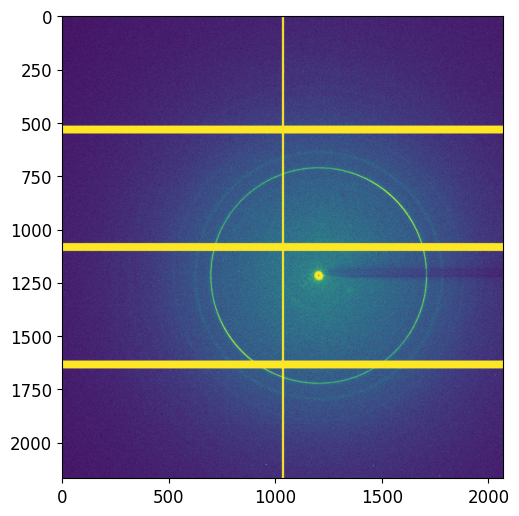

In [44]:
path = r"E:\PEG_g_PLA Nikos 2025\Polina_July2026\polina\polina_p236B_110C\scan00001\eiger\polina_p236B_110C_00001_data_000000.h5"

File = h5py.File(path, 'r')
img = File['entry_0000']['measurement']['data'][:][0]

plt.imshow(img, vmin=0, vmax=20)

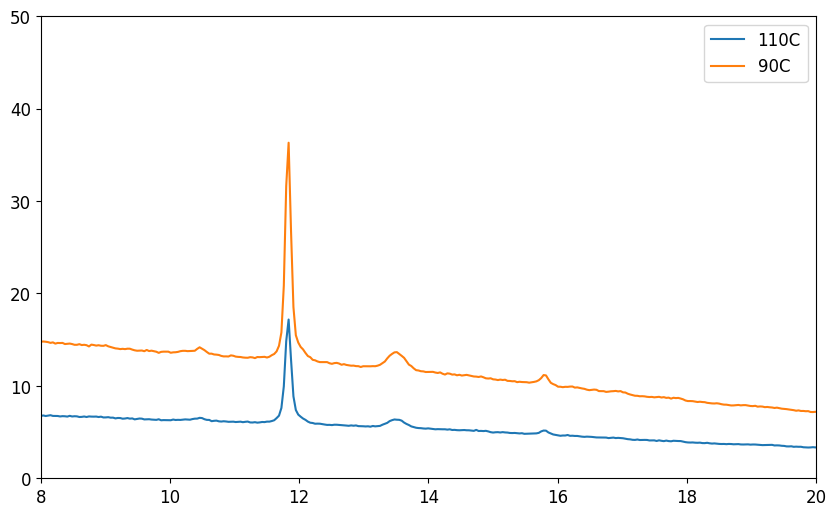

In [58]:
path = r"E:\PEG_g_PLA Nikos 2025\Polina_July2026\polina\polina_p236B_110C\scan00001\eiger\polina_p236B_110C_00001_data_000000.h5"

File = h5py.File(path, 'r')
img = File['entry_0000']['measurement']['data'][:][0]
q, I = ai.integrate1d(img, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q, I, label='110C')

path = r"E:\PEG_g_PLA Nikos 2025\Polina_July2026\polina\polina_p236B_90C\scan00003\eiger\polina_p236B_90C_00003_data_000000.h5"

File = h5py.File(path, 'r')
img = File['entry_0000']['measurement']['data'][:][0]
q, I = ai.integrate1d(img, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q, I, label='90C')

plt.xlim([8, 20])
plt.ylim(0, 50)
plt.legend()

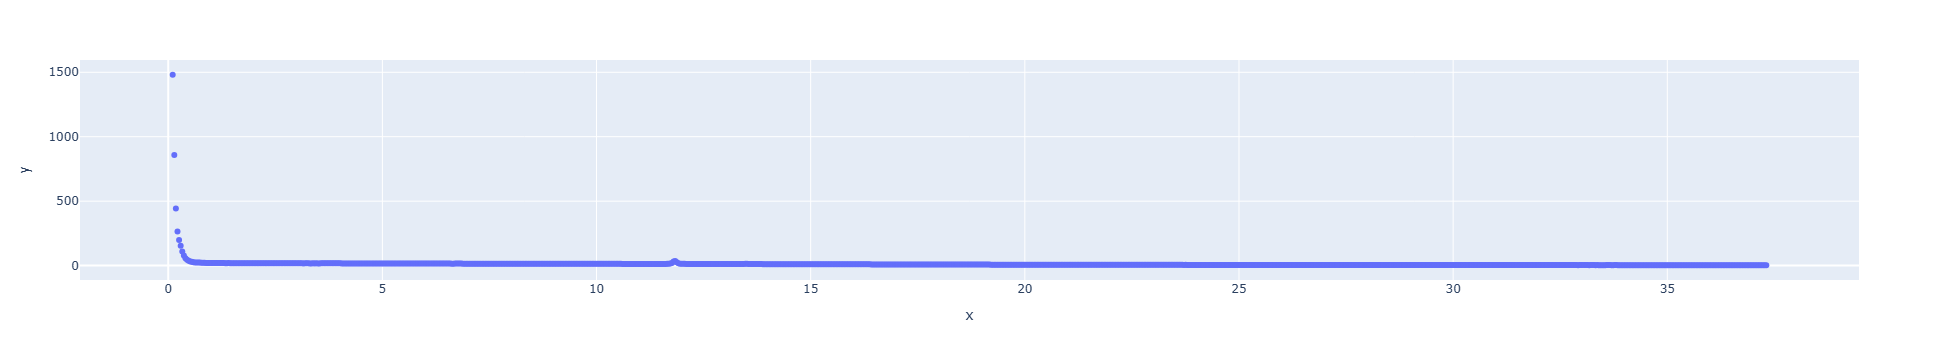

In [62]:
px.scatter(x=q, y=I)

In [63]:
2 * pi / 11.83

0.5311230183583758

In [60]:
path = r'G:\IHSC1942\RAW_DATA\Linkam_Capill\Linkam_Capill_Lada_MCR_OEGA_nx_1101_water_heating5_80C'

Exp = BM26_experiment(path)

Found 48 EDF files in SAXS


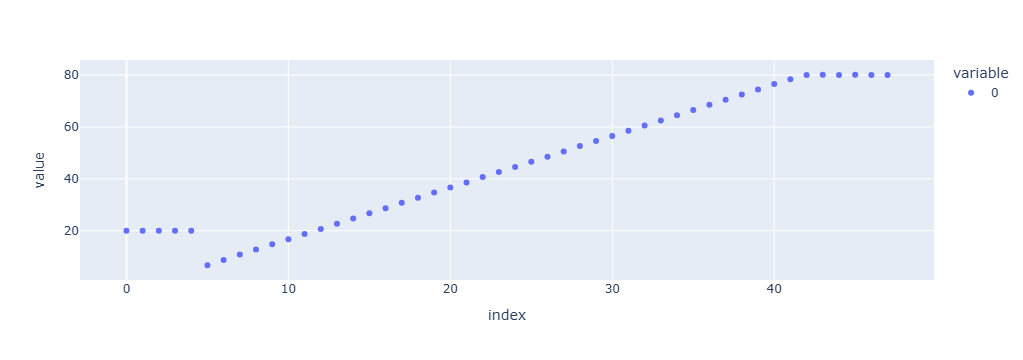

In [61]:
px.scatter(Exp.get_T_profile())